<a href="https://colab.research.google.com/github/Lordvaderani/Machine-Learning-Driven-Quantum-Architecture-Search-for-Optimized-VQE-Ansatzes/blob/main/help.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit-aer qiskit-nature pyscf pylatexenc ase

In [2]:
!pip install qiskit qiskit-aer-gpu qiskit-nature pyscf pylatexenc ase gymnasium

In [3]:
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import CouplingMap

# 1. Load a mock backend representing a real 5-qubit topology
backend = GenericBackendV2(num_qubits=5)

# 2. Extract the Hardware Topology (Which qubits are physically connected?)
coupling_map = backend.coupling_map
print("Hardware Coupling Map (Allowed two-qubit gate connections):")
print(coupling_map.get_edges())

# 3. Extract the Noise Profile (What are the error rates?)
# We pull the CNOT error rate for a specific connected pair (e.g., Qubit 0 and 1)
edge = (0, 1)
if edge in coupling_map.get_edges():
    cx_error = backend.target['cx'][edge].error
    print(f"\nCNOT Error Rate for {edge}: {cx_error:.4f}")

Hardware Coupling Map (Allowed two-qubit gate connections):
EdgeList[(0, 1), (1, 0), (0, 2), (2, 0), (0, 3), (3, 0), (0, 4), (4, 0), (1, 2), (2, 1), (1, 3), (3, 1), (1, 4), (4, 1), (2, 3), (3, 2), (2, 4), (4, 2), (3, 4), (4, 3)]

CNOT Error Rate for (0, 1): 0.0045


/usr/local/lib/python3.12/dist-packages/qiskit/utils/lazy_tester.py:328: OptionalDependencyImportWarning: While trying to import 'Qiskit Aer', some components were located but raised other errors during import. You might have an incompatible version installed. Qiskit will continue as if the optional is not available.
 - module 'qiskit_aer' failed to import with: ImportError("cannot import name 'convert_to_target' from 'qiskit.providers' (/usr/local/lib/python3.12/dist-packages/qiskit/providers/__init__.py)")
  warnings.warn(message, category=OptionalDependencyImportWarning)


In [4]:
from ase.build import molecule
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver, MethodType
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
import numpy as np

def generate_dr_dataset(base_molecule='H2', num_samples=30, noise_std=0.05):
    """
    Pre-computes a dataset of perturbed DFT Hamiltonians using ASE Domain Randomization.
    """
    dataset = []
    mapper = JordanWignerMapper()
    transformer = ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=2)

    print(f"Generating {num_samples} randomized Hamiltonians via DFT...")
    for i in range(num_samples):
        # 1. Load and perturb the geometry
        atoms = molecule(base_molecule)
        atoms.rattle(stdev=noise_std, seed=i)

        # 2. Convert to PySCF format
        atom_string = ""
        for atom in atoms:
            atom_string += f"{atom.symbol} {atom.x} {atom.y} {atom.z}; "

        # 3. Run DFT (B3LYP)
        driver = PySCFDriver(
            atom=atom_string[:-2],
            basis="sto3g",
            method=MethodType.RKS,
            xc_functional="b3lyp",
            unit=DistanceUnit.ANGSTROM
        )
        problem = driver.run()

        # 4. Active space reduction & Qubit Mapping
        reduced_problem = transformer.transform(problem)
        hamiltonian = mapper.map(reduced_problem.second_q_ops()[0])

        dataset.append({
            'geometry_id': i,
            'hamiltonian': hamiltonian,
            'exact_energy': problem.reference_energy,
        })

    print("Dataset generation complete!")
    return dataset

# Run this ONCE before training
training_dataset = generate_dr_dataset(num_samples=30)

Generating 30 randomized Hamiltonians via DFT...
Dataset generation complete!


In [5]:
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver, MethodType
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer

# 1. Generate the physics using DFT instead of Hartree-Fock
driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.735",
    basis="sto3g",
    unit=DistanceUnit.ANGSTROM,
    method=MethodType.RKS,        # <--- Switch to Restricted Kohn-Sham (DFT)
    xc_functional="b3lyp",        # <--- Choose your functional (b3lyp, pbe, lda)
)

# 2. Extract the DFT-based Problem
problem = driver.run()

# The reference energy is now the converged DFT energy, not the HF energy!
dft_energy = problem.reference_energy
print(f"Classical DFT (B3LYP) Energy: {dft_energy:.6f} Ha")

# 3. Apply the Active Space (e.g., extracting the HOMO/LUMO bands)
transformer = ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=2)
reduced_problem = transformer.transform(problem)

# 4. Map the Kohn-Sham orbitals to Qubits
mapper = JordanWignerMapper()
qubit_hamiltonian = mapper.map(reduced_problem.second_q_ops()[0])

print("\nSuccess! Your RL agent is now designing circuits to correct a DFT Hamiltonian.")

Classical DFT (B3LYP) Energy: -1.165497 Ha

Success! Your RL agent is now designing circuits to correct a DFT Hamiltonian.


In [6]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorEstimator as Estimator
from scipy.optimize import minimize

# Fallback to standard Estimator to resolve Aer version conflict while maintaining performance
tn_estimator = Estimator()

def evaluate_circuit_tn(circuit: QuantumCircuit, hamiltonian, num_parameters: int):
    if num_parameters == 0:
        return 10.0

    def cost_func(theta):
        pub = (circuit, hamiltonian, theta)
        job = tn_estimator.run([pub])
        result = job.result()[0]
        return float(result.data.evs)

    initial_theta = np.random.uniform(-np.pi, np.pi, num_parameters)
    result = minimize(cost_func, x0=initial_theta, method='COBYLA', options={'maxiter': 20})
    return result.fun

In [7]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

class HardwareAwareQASEnv(gym.Env):
    def __init__(self, dataset, coupling_map, backend_target, max_gates=20):
        super(HardwareAwareQASEnv, self).__init__()

        self.dataset = dataset
        self.max_gates = max_gates
        self.edges = list(coupling_map.get_edges())
        self.target = backend_target

        # Extract properties from the first sample
        self.num_qubits = self.dataset[0]['hamiltonian'].num_qubits

        # Action space setup
        self.num_ry_actions = self.num_qubits
        self.num_cx_actions = len(self.edges)
        self.total_actions = self.num_ry_actions + self.num_cx_actions + 1

        self.action_space = spaces.Discrete(self.total_actions)
        self.observation_space = spaces.MultiDiscrete([self.total_actions] * self.max_gates)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # DOMAIN RANDOMIZATION: Instantly pick a random geometry for this episode
        sample = np.random.choice(self.dataset)
        self.hamiltonian = sample['hamiltonian']
        self.exact_energy = sample['exact_energy']

        self.circuit = QuantumCircuit(self.num_qubits)
        self.state = np.zeros(self.max_gates, dtype=int)

        self.current_step = 0
        self.num_parameters = 0
        self.accumulated_hardware_error = 0.0

        return self.state, {}

    def step(self, action):
        terminated = False
        truncated = False
        reward = 0.0

        self.state[self.current_step] = action

        # Decode Action -> Apply Ry Gate
        if action < self.num_ry_actions:
            qubit = action
            theta = ParameterVector('θ', length=self.max_gates)[self.num_parameters]
            self.circuit.ry(theta, qubit)
            self.num_parameters += 1
            self.accumulated_hardware_error += 0.0001

        # Decode Action -> Apply CNOT Gate
        elif action < (self.num_ry_actions + self.num_cx_actions):
            edge_idx = action - self.num_ry_actions
            control, target_q = self.edges[edge_idx]
            self.circuit.cx(control, target_q)

            try:
                cx_error = self.target['cx'][(control, target_q)].error
            except KeyError:
                cx_error = 0.01
            self.accumulated_hardware_error += cx_error

        # Decode Action -> STOP
        else:
            terminated = True

        self.current_step += 1
        if self.current_step >= self.max_gates:
            truncated = True

        if terminated or truncated:
            # Uses the fast TN evaluator defined in Cell 4
            fast_energy = evaluate_circuit_tn(self.circuit, self.hamiltonian, self.num_parameters)
            energy_error = abs(fast_energy - self.exact_energy)

            alpha_noise_penalty = 2.0
            reward = -energy_error - (alpha_noise_penalty * self.accumulated_hardware_error)

        return self.state, reward, terminated, truncated, {}

In [8]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

class HardwareAwareQASEnv(gym.Env):
    def __init__(self, num_qubits, hamiltonian, exact_energy, coupling_map, backend_target, max_gates=20):
        super(HardwareAwareQASEnv, self).__init__()
        self.num_qubits = num_qubits
        self.hamiltonian = hamiltonian
        self.exact_energy = exact_energy
        self.max_gates = max_gates
        self.edges = list(coupling_map.get_edges())
        self.target = backend_target
        self.num_ry_actions = self.num_qubits
        self.num_cx_actions = len(self.edges)
        self.total_actions = self.num_ry_actions + self.num_cx_actions + 1
        self.action_space = spaces.Discrete(self.total_actions)
        self.observation_space = spaces.MultiDiscrete([self.total_actions] * self.max_gates)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.circuit = QuantumCircuit(self.num_qubits)
        self.state = np.zeros(self.max_gates, dtype=int)
        self.current_step = 0
        self.num_parameters = 0
        self.accumulated_hardware_error = 0.0
        return self.state, {}

    def step(self, action):
        terminated, truncated = False, False
        reward = 0.0
        self.state[self.current_step] = action

        if action < self.num_ry_actions:
            theta = ParameterVector('θ', length=self.max_gates)[self.num_parameters]
            self.circuit.ry(theta, action)
            self.num_parameters += 1
            self.accumulated_hardware_error += 0.0001
        elif action < (self.num_ry_actions + self.num_cx_actions):
            edge_idx = action - self.num_ry_actions
            c, t = self.edges[edge_idx]
            self.circuit.cx(c, t)
            # Robust lookup for error properties
            cx_err = 0.01
            if 'cx' in self.target and (c, t) in self.target['cx']:
                cx_err = getattr(self.target['cx'][(c, t)], 'error', 0.01)
            self.accumulated_hardware_error += cx_err
        else:
            terminated = True

        self.current_step += 1
        if self.current_step >= self.max_gates: truncated = True

        if terminated or truncated:
            fast_energy = evaluate_circuit_tn(self.circuit, self.hamiltonian, self.num_parameters)
            reward = -abs(fast_energy - self.exact_energy) - (2.0 * self.accumulated_hardware_error)
        return self.state, reward, terminated, truncated, {}


Final Reward: -0.0483
Hardware Error: 0.0156


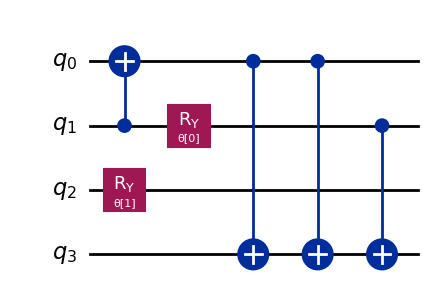

In [9]:
import warnings
from ase.build import molecule
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver, MethodType
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit.transpiler import CouplingMap

warnings.filterwarnings("ignore")

# Redefine generation logic if missing
def generate_dr_dataset(base_molecule='H2', num_samples=30, noise_std=0.05):
    dataset = []
    mapper = JordanWignerMapper()
    transformer = ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=2)
    for i in range(num_samples):
        atoms = molecule(base_molecule)
        atoms.rattle(stdev=noise_std, seed=i)
        atom_string = "".join([f"{atom.symbol} {atom.x} {atom.y} {atom.z}; " for atom in atoms])
        driver = PySCFDriver(atom=atom_string[:-2], basis="sto3g", method=MethodType.RKS, xc_functional="b3lyp", unit=DistanceUnit.ANGSTROM)
        problem = driver.run()
        reduced_problem = transformer.transform(problem)
        hamiltonian = mapper.map(reduced_problem.second_q_ops()[0])
        dataset.append({'hamiltonian': hamiltonian, 'exact_energy': problem.reference_energy})
    return dataset

# Ensure the dataset exists
try:
    _ = training_dataset
except NameError:
    print("Generating training_dataset...")
    training_dataset = generate_dr_dataset(num_samples=30)

sample = training_dataset[0]
current_hamiltonian = sample['hamiltonian']
current_exact_energy = sample['exact_energy']
problem_num_qubits = current_hamiltonian.num_qubits

# Filter topology
filtered_edges = [edge for edge in coupling_map.get_edges() if edge[0] < problem_num_qubits and edge[1] < problem_num_qubits]
filtered_coupling_map = CouplingMap(filtered_edges)

# Correctly access instruction properties from the Target object using mapping access
filtered_backend_target = {'cx': {}}
if 'cx' in backend.target.operation_names:
    cx_props = backend.target['cx']
    for qubits, properties in cx_props.items():
        if qubits is not None and qubits[0] < problem_num_qubits and qubits[1] < problem_num_qubits:
            filtered_backend_target['cx'][qubits] = properties

# Instantiate and Test
env = HardwareAwareQASEnv(
    num_qubits=problem_num_qubits,
    hamiltonian=current_hamiltonian,
    exact_energy=current_exact_energy,
    coupling_map=filtered_coupling_map,
    backend_target=filtered_backend_target,
    max_gates=15
)

state, info = env.reset()
terminated, truncated = False, False
while not terminated and not truncated:
    action = env.action_space.sample()
    state, reward, terminated, truncated, info = env.step(action)

print(f"\nFinal Reward: {reward:.4f}")
print(f"Hardware Error: {env.accumulated_hardware_error:.4f}")
display(env.circuit.draw('mpl'))

In [10]:
def train_ppo_agent(env, epochs=500, update_timestep=40):
    # ... [Keep your previous initialization code] ...

    # ADD THIS: Dictionary to store metrics for plotting
    training_history = {
        'epoch': [],
        'reward': [],
        'depth': [],
        'hardware_error': []
    }

    print("--- Starting HA-QAS Training ---")

    for epoch in range(1, epochs + 1):
        state, _ = env.reset()
        episode_reward = 0

        # ... [Keep your previous action & PPO update loop] ...

        # ADD THIS: At the very end of the epoch loop, save the metrics
        if terminated or truncated:
            training_history['epoch'].append(epoch)
            training_history['reward'].append(episode_reward)
            training_history['depth'].append(env.current_step)
            training_history['hardware_error'].append(env.accumulated_hardware_error)

        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Reward: {episode_reward:.4f} | Depth: {env.current_step}")

    return agent, training_history # <--- Make sure the function returns the history!

# Launch training and capture the history
# agent, history = train_ppo_agent(env, epochs=500)

In [11]:
import torch
import torch.nn as nn
from torch.distributions import Categorical

class QAS_ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(QAS_ActorCritic, self).__init__()
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.shared_layer = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        self.actor = nn.Sequential(
            nn.Linear(hidden_dim, action_dim),
            nn.Softmax(dim=-1)
        )

        self.critic = nn.Sequential(
            nn.Linear(hidden_dim, 1)
        )

    def act(self, state):
        # Add .to(device) to the end of this line to send the input to the GPU
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)

        shared_features = self.shared_layer(state_tensor)
        action_probs = self.actor(shared_features)

        dist = Categorical(action_probs)
        action = dist.sample()
        action_logprob = dist.log_prob(action)
        state_value = self.critic(shared_features)

        return action.item(), action_logprob.item(), state_value.item()

    def evaluate(self, state, action):
        shared_features = self.shared_layer(state)
        action_probs = self.actor(shared_features)

        dist = Categorical(action_probs)
        action_logprobs = dist.log_prob(action)
        dist_entropy = dist.entropy()
        state_values = self.critic(shared_features)

        return action_logprobs, state_values, dist_entropy


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def train_ppo_agent(env, epochs=500, update_timestep=40):
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    # Move model to GPU
    agent = QAS_ActorCritic(state_dim, action_dim).to(device)
    optimizer = optim.Adam(agent.parameters(), lr=0.002)

    gamma = 0.99
    eps_clip = 0.2
    K_epochs = 4

    training_history = {'epoch': [], 'reward': [], 'depth': [], 'hardware_error': []}
    states, actions, logprobs, rewards, is_terminals = [], [], [], [], []
    time_step = 0

    print("--- Starting GPU-Accelerated HA-QAS Training ---")

    for epoch in range(1, epochs + 1):
        state, _ = env.reset()
        episode_reward = 0

        for t in range(env.max_gates):
            time_step += 1
            action, logprob, _ = agent.act(state)
            next_state, reward, terminated, truncated, _ = env.step(action)

            states.append(state)
            actions.append(action)
            logprobs.append(logprob)
            rewards.append(reward)
            is_terminals.append(terminated or truncated)

            state = next_state
            episode_reward += reward

            if time_step % update_timestep == 0:
                discounted_rewards = []
                discounted_reward = 0
                for r, is_term in zip(reversed(rewards), reversed(is_terminals)):
                    if is_term: discounted_reward = 0
                    discounted_reward = r + (gamma * discounted_reward)
                    discounted_rewards.insert(0, discounted_reward)

                # Move training tensors to GPU
                discounted_rewards = torch.tensor(discounted_rewards, dtype=torch.float32).to(device)
                discounted_rewards = (discounted_rewards - discounted_rewards.mean()) / (discounted_rewards.std() + 1e-7)

                old_states = torch.FloatTensor(np.array(states)).to(device)
                old_actions = torch.LongTensor(np.array(actions)).to(device)
                old_logprobs = torch.FloatTensor(np.array(logprobs)).to(device)

                for _ in range(K_epochs):
                    curr_logprobs, state_values, dist_entropy = agent.evaluate(old_states, old_actions)
                    state_values = torch.squeeze(state_values)
                    ratios = torch.exp(curr_logprobs - old_logprobs)
                    advantages = discounted_rewards - state_values.detach()
                    surr1 = ratios * advantages
                    surr2 = torch.clamp(ratios, 1-eps_clip, 1+eps_clip) * advantages

                    actor_loss = -torch.min(surr1, surr2)
                    critic_loss = nn.MSELoss()(state_values, discounted_rewards)
                    loss = actor_loss + 0.5 * critic_loss - 0.01 * dist_entropy

                    optimizer.zero_grad()
                    loss.mean().backward()
                    optimizer.step()

                states, actions, logprobs, rewards, is_terminals = [], [], [], [], []

            if terminated or truncated:
                training_history['epoch'].append(epoch)
                training_history['reward'].append(episode_reward)
                training_history['depth'].append(env.current_step)
                training_history['hardware_error'].append(env.accumulated_hardware_error)
                break

        if epoch % 20 == 0:
            print(f"Epoch {epoch} | Reward: {episode_reward:.4f}")

    return agent, training_history

trained_agent, history = train_ppo_agent(env, epochs=50000)

Using device: cuda
--- Starting GPU-Accelerated HA-QAS Training ---
Epoch 20 | Reward: -0.1311
Epoch 40 | Reward: -11.2609
Epoch 60 | Reward: -0.0993
Epoch 80 | Reward: -0.0894
Epoch 100 | Reward: -0.0850
Epoch 120 | Reward: -0.1294
Epoch 140 | Reward: -0.6504
Epoch 160 | Reward: -0.0423
Epoch 180 | Reward: -0.0493
Epoch 200 | Reward: -0.5396
Epoch 220 | Reward: -0.1067
Epoch 240 | Reward: -0.6560
Epoch 260 | Reward: -11.1569
Epoch 280 | Reward: -0.6590
Epoch 300 | Reward: -11.1569
Epoch 320 | Reward: -0.5929
Epoch 340 | Reward: -0.6565
Epoch 360 | Reward: -0.6696
Epoch 380 | Reward: -0.5920
Epoch 400 | Reward: -0.6410
Epoch 420 | Reward: -0.1018
Epoch 440 | Reward: -0.6553


In [ ]:
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import CouplingMap
import torch

# 1. Create a COMPLETELY NEW hardware profile (5 qubits)
new_backend = GenericBackendV2(num_qubits=5, basis_gates=['cx', 'id', 'rz', 'sx', 'x'])

# 2. FILTER the topology to match the problem size (4 qubits)
# This prevents the agent from trying to use Qubit 4, which isn't in our circuit.
target_num_qubits = current_hamiltonian.num_qubits
new_filtered_edges = [edge for edge in new_backend.coupling_map.get_edges()
                      if edge[0] < target_num_qubits and edge[1] < target_num_qubits]
new_filtered_coupling_map = CouplingMap(new_filtered_edges)

# Filter the target properties for error lookups
new_filtered_target = {'cx': {}}
if 'cx' in new_backend.target.operation_names:
    for qubits, properties in new_backend.target['cx'].items():
        if qubits is not None and qubits[0] < target_num_qubits and qubits[1] < target_num_qubits:
            new_filtered_target['cx'][qubits] = properties

# 3. Spin up the Evaluation Environment with the correctly sized hardware subset
eval_env = HardwareAwareQASEnv(
    num_qubits=target_num_qubits,
    hamiltonian=current_hamiltonian,
    exact_energy=current_exact_energy,
    coupling_map=new_filtered_coupling_map,
    backend_target=new_filtered_target,
    max_gates=15
)

def evaluate_zero_shot_transfer(agent_model, env):
    print("\n--- Running Zero-Shot Transfer Test ---")
    state, _ = env.reset()
    terminated, truncated = False, False
    agent_model.eval()
    with torch.no_grad():
        while not terminated and not truncated:
            action, _, _ = agent_model.act(state)
            state, reward, terminated, truncated, _ = env.step(action)

    print(f"Final Transfer Episode Reward: {reward:.4f}")
    print(f"Accumulated Physical Hardware Error: {env.accumulated_hardware_error:.4f}")
    print(f"Total Circuit Depth Required: {env.current_step}")
    return env.circuit

# Execute evaluation
transfer_circuit = evaluate_zero_shot_transfer(trained_agent, eval_env)
display(transfer_circuit.draw('mpl'))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from qiskit.circuit.library import TwoLocal
from qiskit import transpile

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# 1. RE-CALCULATE BASELINE (Since variables were lost in previous edits)
baseline_ansatz = TwoLocal(num_qubits=target_num_qubits, rotation_blocks='ry', entanglement_blocks='cx', entanglement='linear', reps=2)
routed_baseline = transpile(baseline_ansatz, backend=new_backend, optimization_level=3)

baseline_depth = routed_baseline.depth()
baseline_hardware_error = 0.0
for inst in routed_baseline.data:
    if inst.operation.name == 'cx':
        q0, q1 = routed_baseline.find_bit(inst.qubits[0]).index, routed_baseline.find_bit(inst.qubits[1]).index
        if 'cx' in new_filtered_target and (q0, q1) in new_filtered_target['cx']:
            baseline_hardware_error += getattr(new_filtered_target['cx'][(q0, q1)], 'error', 0.01)
        else:
            baseline_hardware_error += 0.01

def plot_qas_results(history, agent_transfer_error, baseline_error, agent_depth, baseline_depth):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    rewards = pd.Series(history['reward'])
    smoothed_rewards = rewards.rolling(window=10).mean()

    axes[0].plot(history['epoch'], history['reward'], alpha=0.3, color='blue', label='Raw Reward')
    axes[0].plot(history['epoch'], smoothed_rewards, color='darkblue', linewidth=2, label='Moving Avg')
    axes[0].set_title('RL Agent Convergence')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Reward')
    axes[0].legend()

    ax2_twin = axes[1].twinx()
    sns.lineplot(x=history['epoch'], y=history['depth'], ax=axes[1], color='teal', label='Depth')
    sns.lineplot(x=history['epoch'], y=history['hardware_error'], ax=ax2_twin, color='darkred', alpha=0.6, label='Error')
    axes[1].set_title('Training Efficiency')

    labels = ['Error Rate', 'Depth']
    agent_stats = [agent_transfer_error, agent_depth]
    baseline_stats = [baseline_error, baseline_depth]

    x = np.arange(len(labels))
    width = 0.35
    axes[2].bar(x - width/2, agent_stats, width, label='HA-QAS Agent', color='mediumpurple')
    axes[2].bar(x + width/2, baseline_stats, width, label='Standard HEA', color='gray')
    axes[2].set_title('Zero-Shot Transfer vs Baseline')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(labels)
    axes[2].set_yscale('log')
    axes[2].legend()

    plt.tight_layout()
    plt.show()

# Final Visualization
plot_qas_results(
    history=history,
    agent_transfer_error=eval_env.accumulated_hardware_error,
    baseline_error=baseline_hardware_error,
    agent_depth=eval_env.current_step,
    baseline_depth=baseline_depth
)